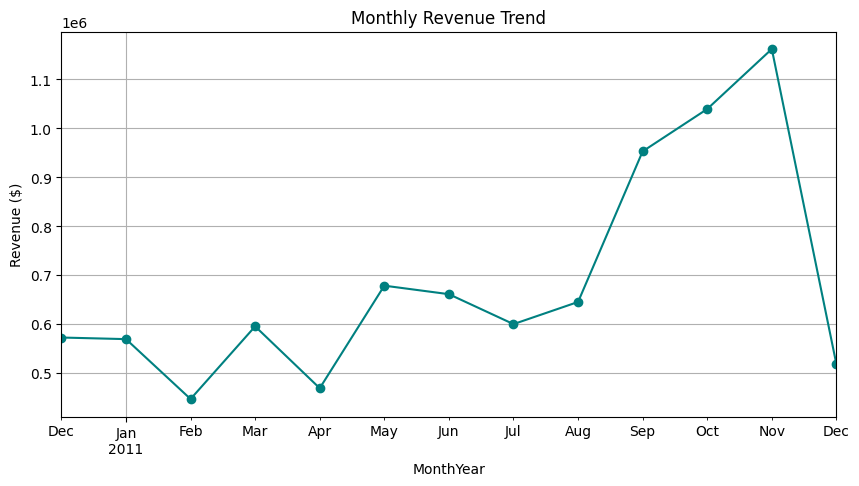

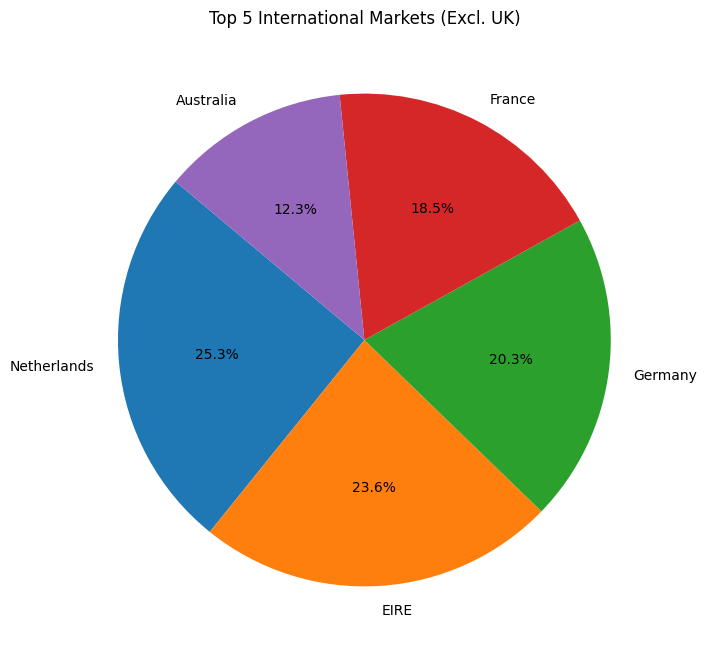

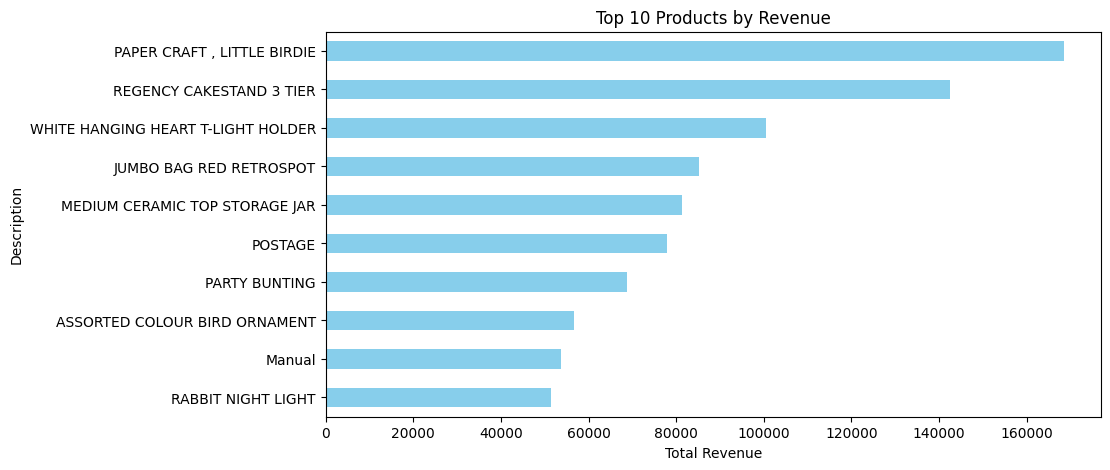

In [2]:
import pandas as pd
df=pd.read_excel(r'C:\Users\hp\OneDrive\Desktop\online_retail.csv.xlsx')
df=df.dropna(subset=['CustomerID'])
df=df[~df['InvoiceNo'].str.contains('C',na=False)]
df=df[(df['Quantity']>0)&(df['UnitPrice']>0)]
df['Revenue']=df['Quantity']*df['UnitPrice']
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])
import matplotlib.pyplot as plt
df['MonthYear'] = df['InvoiceDate'].dt.to_period('M')
monthly_revenue = df.groupby('MonthYear')['Revenue'].sum()
monthly_revenue.plot(kind='line', marker='o', figsize=(10, 5), color='teal')
plt.title('Monthly Revenue Trend')
plt.ylabel('Revenue ($)')
plt.grid(True)
plt.show()
international_sales = df[df['Country'] != 'United Kingdom']
top_countries = international_sales.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(5)
plt.figure(figsize=(8, 8))
plt.pie(top_countries, labels=top_countries.index, autopct='%1.1f%%', startangle=140)
plt.title('Top 5 International Markets (Excl. UK)')
plt.show()
top_products = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)
top_products.plot(kind='barh', figsize=(10, 5), color='skyblue')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Total Revenue')
plt.gca().invert_yaxis() 
plt.show()
